## WINE QUALITY ANALISIS 

In this project, a wine quality analysis will be performed using machine learning techniques. A dataset containing information on different chemical characteristics of wine and its quality will be used, with the objective of building a model that can predict wine quality based on these characteristics

# Exploration Phase:
The dataset consists of 1,600 rows and 12 variables. Of these, 11 represent wine characteristics, while the final variable is the quality—with values ranging from 0 to 10—which serves as our target variable for prediction.

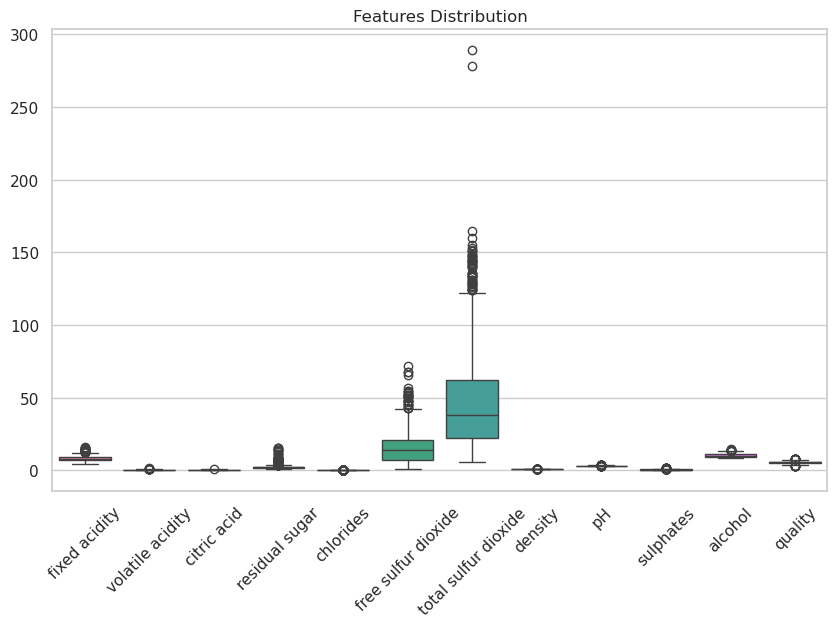

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

df = pd.read_csv('winequality.csv')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df)

plt.title('Features Distribution')
plt.xticks(rotation=45)
plt.show()


We observe a clear skewed distribution in the variables related to sulfur dioxide, which requires us to standardize the features when building the model.

The boxplot above shows a strongly right-skewed distribution in the sulfur dioxide variables, with a few isolated wines far above the rest. Rows with total sulfur dioxide greater than 250 are therefore removed before splitting and standardizing the data as those values can inflate the mean and standard deviation used by StandardScaler.

In [80]:
df = df[df['total sulfur dioxide'] <= 250]

Next, we will analyze the correlation between the variables to identify which ones are most strongly correlated with wine quality.

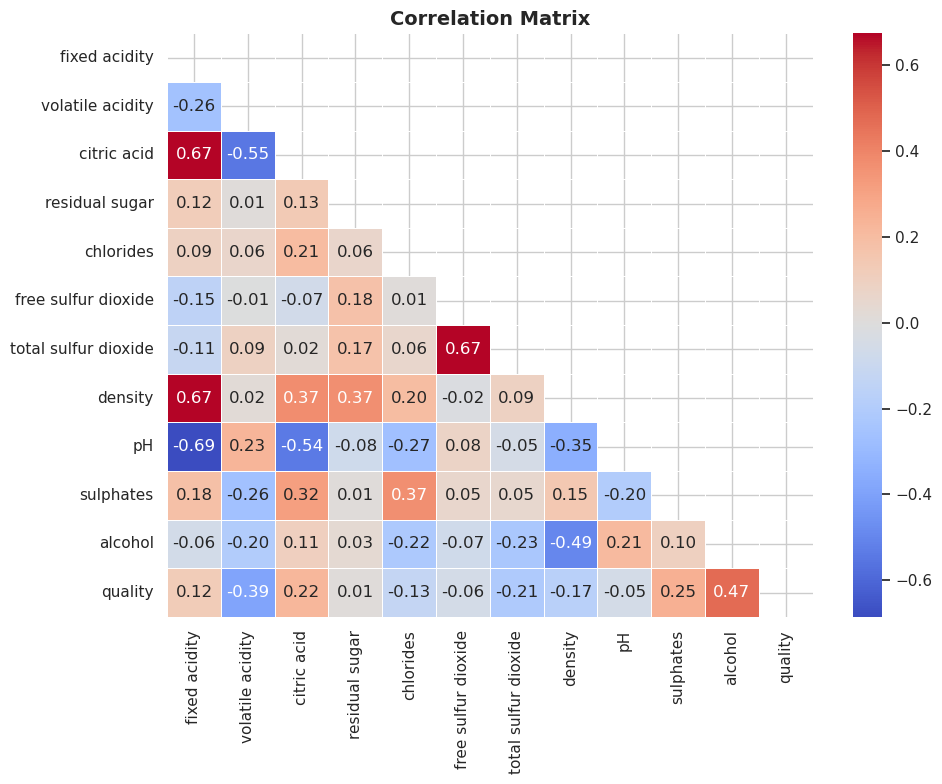

In [81]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



We see that alcohol is a strong predictor of wine quality, showing a correlation of 0.44, which indicates that wines with a higher ABV (alcohol by volume) tend to receive higher ratings. Conversely, factors like density and acidity are associated with lower wine quality.

# Modeling Phase

c:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Logistic Regression: Train accuracy = 0.8802 | Test accuracy = 0.8812
KNN: Train accuracy = 0.9084 | Test accuracy = 0.8781
SVM: Train accuracy = 0.8974 | Test accuracy = 0.8938
Neural Network: Train accuracy = 0.9984 | Test accuracy = 0.9031
Random Forest: Train accuracy = 1.0000 | Test accuracy = 0.9219
XGBoost: Train accuracy = 1.0000 | Test accuracy = 0.9187


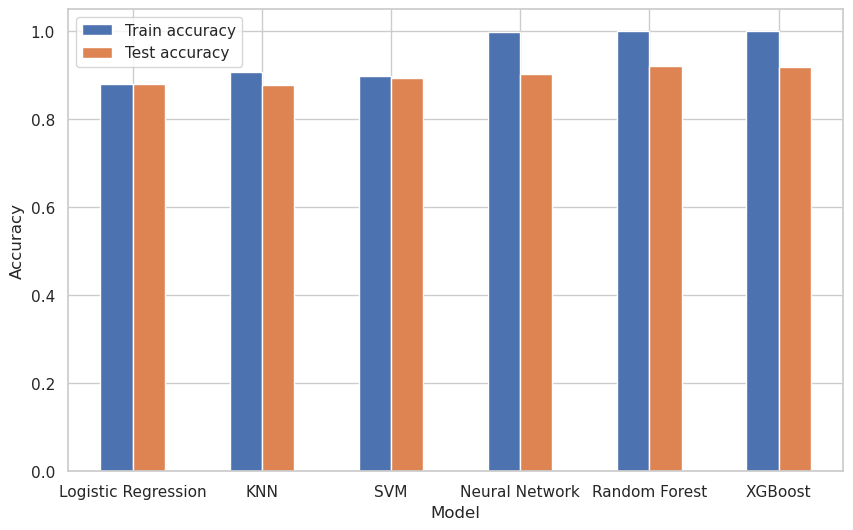

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score

df = df.dropna()
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, ytrain, ytest = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(X_train)
Xtest_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNN(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42),
}
results = []
for name, clf in models.items():
    clf.fit(Xtrain_scaled, ytrain)
    results.append({
        'Model': name,
        'Train accuracy': accuracy_score(ytrain, clf.predict(Xtrain_scaled)),
        'Test accuracy': accuracy_score(ytest, clf.predict(Xtest_scaled)),
    })
for r in results:
    print(f"{r['Model']}: Train accuracy = {r['Train accuracy']:.4f} | Test accuracy = {r['Test accuracy']:.4f}")

pd.DataFrame(results).set_index('Model').plot.bar(figsize=(10, 6), rot=0)
plt.ylabel('Accuracy')
plt.show()